# TECH 405 — Exploratory Data Analysis and Feature Engineering
## Dataset Selection for Neural Network Implementation (CNN Track)

**Project:** AI-Based Vegetable and Fruit Freshness Detection Using CNN
**Dataset:** [Fruits and Vegetables dataset](https://www.kaggle.com/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset) by Muhriddin Mukhiddinov (Kaggle)
**Student:** Chris
**Supervisor:** Prof. Bibek Khanal

### Objective
This notebook explores a publicly available image dataset that will be used to train a Convolutional
Neural Network (CNN) in the next assignment. The dataset contains images of five fruits (apple, banana,
orange, mango, strawberry) and five vegetables (tomato, cucumber, carrot, potato, bell pepper), each
labeled as **fresh** or **rotten**, for a total of 20 classes and roughly 12,000 images.

This notebook covers:
1. Dataset acquisition
2. Directory structure and class distribution
3. Sample image inspection
4. Image dimension and aspect ratio analysis
5. Color and brightness analysis (fresh vs. rotten)
6. Data quality checks (corrupt / unreadable files)
7. Feature engineering for the CNN pipeline (resizing, normalization, splitting, augmentation, class balance)


## 1. Setup

In [1]:
# Core libraries
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 2. Dataset Acquisition

The dataset can be obtained either of two ways:

**Option A — manual download (no setup required):** go to the
[dataset page](https://www.kaggle.com/datasets/muhriddinmuxiddinov/fruits-and-vegetables-dataset),
click Download, then extract the zip file somewhere on disk (e.g.
`C:\Users\Chris\Downloads\fruit_veg_data`).

**Option B — Kaggle API:** requires a `kaggle.json` API token (from your Kaggle account settings)
placed in `~/.kaggle/kaggle.json`, then the commented `!kaggle datasets download` line below.

Set `RAW_DATA_DIR` to wherever you extracted (or downloaded) the dataset. The next cell will
automatically search inside it for the folder level that actually contains the class folders
(e.g. `freshapples`, `rottenbanana`, ...), so it does not matter if the zip added an extra wrapper
folder.

In [2]:
# Uncomment to download via the Kaggle API instead of downloading manually
# !pip install -q kaggle
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d muhriddinmuxiddinov/fruits-and-vegetables-dataset -p ./data --unzip

RAW_DATA_DIR = r"C:\Users\Chris\Downloads\fruit_veg_data"  # <-- update to your actual extracted folder

if not os.path.exists(RAW_DATA_DIR):
    raise FileNotFoundError(
        f"RAW_DATA_DIR does not exist: {RAW_DATA_DIR}\n"
        "Download the dataset from Kaggle, extract the zip, and update RAW_DATA_DIR above "
        "to point at the extracted folder."
    )
print("RAW_DATA_DIR exists:", RAW_DATA_DIR)


RAW_DATA_DIR exists: C:\Users\Chris\Downloads\fruit_veg_data


### 2.1 Auto-detect the class folder level

This walks the extracted dataset and finds the first directory level where subfolders look like
class folders (their names contain "fresh" or "rotten"). This avoids having to manually figure out
how many levels of wrapper folders the zip added.

In [3]:
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

def looks_like_class_dir(dirpath):
    name = os.path.basename(dirpath).lower()
    return "fresh" in name or "rotten" in name

def find_dataset_root(raw_dir):
    for root, dirs, files in os.walk(raw_dir):
        class_like = [d for d in dirs if looks_like_class_dir(os.path.join(root, d))]
        if len(class_like) >= 2:
            return root
    return None

DATA_DIR = find_dataset_root(RAW_DATA_DIR)

if DATA_DIR is None:
    print("Could not auto-detect class folders under:", RAW_DATA_DIR)
    print("Here is the folder structure found, inspect it and set DATA_DIR manually:\n")
    for root, dirs, files in os.walk(RAW_DATA_DIR):
        depth = root.replace(RAW_DATA_DIR, "").count(os.sep)
        if depth > 3:
            dirs[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root) or root}/  ({len(files)} files)")
    DATA_DIR = RAW_DATA_DIR  # fallback; update manually below if needed
else:
    print("Detected dataset root:", DATA_DIR)
    print("Class folders found:", [d for d in os.listdir(DATA_DIR)
                                    if os.path.isdir(os.path.join(DATA_DIR, d))][:25])


Detected dataset root: C:\Users\Chris\Downloads\fruit_veg_data\Fruits_Vegetables_Dataset(12000)\Fruits
Class folders found: ['FreshApple', 'FreshBanana', 'FreshMango', 'FreshOrange', 'FreshStrawberry', 'RottenApple', 'RottenBanana', 'RottenMango', 'RottenOrange', 'RottenStrawberry']


## 3. Directory Structure and Class Distribution

The dataset is organized as one subfolder per class (e.g. `freshapples`, `rottenapples`,
`freshbanana`, `rottenbanana`, ...). The cell below walks the directory tree, counts images per
class, and derives a `fresh` / `rotten` label and a `produce_type` (apple, banana, tomato, etc.)
from each folder name so we can slice the data multiple ways.

In [4]:
records = []
for root, dirs, files in os.walk(DATA_DIR):
    img_files = [f for f in files if f.lower().endswith(IMG_EXTENSIONS)]
    if not img_files:
        continue
    class_name = os.path.basename(root)
    for f in img_files:
        records.append({
            "filepath": os.path.join(root, f),
            "class_name": class_name,
        })

df = pd.DataFrame(records)

if df.empty:
    raise ValueError(
        f"No images found under DATA_DIR: {DATA_DIR}\n"
        "Check that RAW_DATA_DIR (Section 2) points at your extracted dataset, and that the "
        "auto-detected DATA_DIR printed above actually contains class folders with image files."
    )

def parse_condition(name):
    name_lower = name.lower()
    if "fresh" in name_lower:
        return "fresh"
    if "rotten" in name_lower:
        return "rotten"
    return "unknown"

def parse_produce(name):
    return (
        name.lower()
        .replace("fresh", "")
        .replace("rotten", "")
        .strip("_- ")
    )

df["condition"] = df["class_name"].apply(parse_condition)
df["produce_type"] = df["class_name"].apply(parse_produce)

print(f"Total images found: {len(df):,}")
print(f"Total classes: {df['class_name'].nunique()}")
df.head()


Total images found: 5,988
Total classes: 10


,filepath,class_name,condition,produce_type
0,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,FreshApple,fresh,apple
1,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,FreshApple,fresh,apple
2,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,FreshApple,fresh,apple
3,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,FreshApple,fresh,apple
4,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,FreshApple,fresh,apple


In [5]:
class_counts = df["class_name"].value_counts().sort_index()
class_counts.to_frame("image_count")


,image_count
class_name,
FreshApple,612
FreshBanana,623
FreshMango,605
FreshOrange,609
FreshStrawberry,603
RottenApple,583
RottenBanana,573
RottenMango,593
RottenOrange,591


### 3.1 Class distribution — bar chart

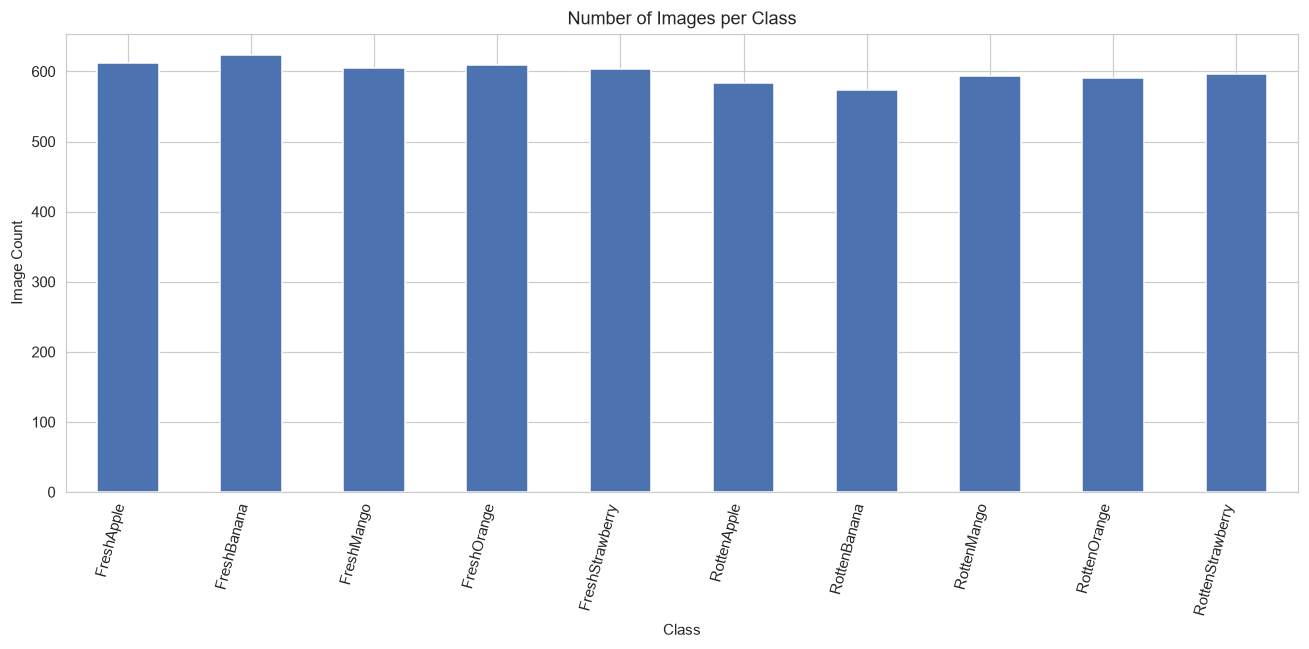

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
class_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Number of Images per Class")
ax.set_xlabel("Class")
ax.set_ylabel("Image Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches="tight")
plt.show()


### 3.2 Fresh vs. rotten balance, and per-produce-type balance

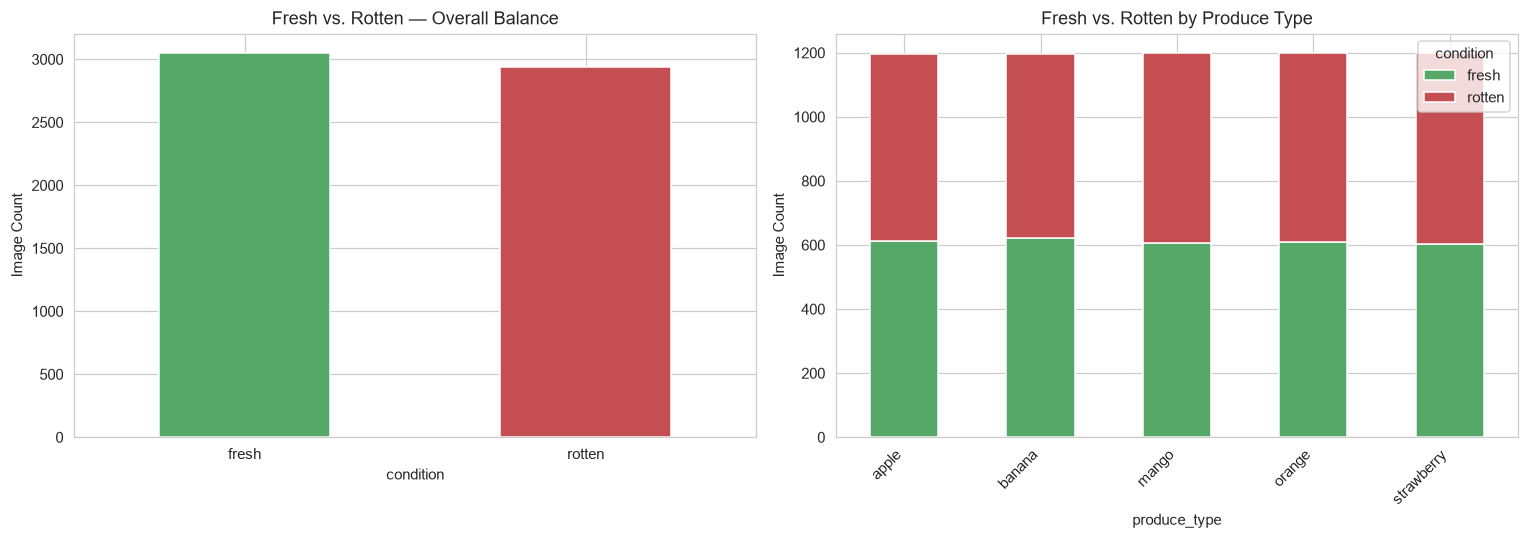

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["condition"].value_counts().plot(kind="bar", ax=axes[0], color=["#55A868", "#C44E52"])
axes[0].set_title("Fresh vs. Rotten — Overall Balance")
axes[0].set_ylabel("Image Count")
axes[0].tick_params(axis="x", rotation=0)

pd.crosstab(df["produce_type"], df["condition"]).plot(
    kind="bar", stacked=True, ax=axes[1], color=["#55A868", "#C44E52"]
)
axes[1].set_title("Fresh vs. Rotten by Produce Type")
axes[1].set_ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fresh_rotten_balance.png", bbox_inches="tight")
plt.show()


**Observation:** classes are roughly balanced (~600 images each per the dataset documentation),
but any deviation shown above should be noted here and carried into the class-imbalance handling
step in Section 7.

## 4. Sample Image Inspection

A quick visual sanity check: one fresh and one rotten sample per produce type.

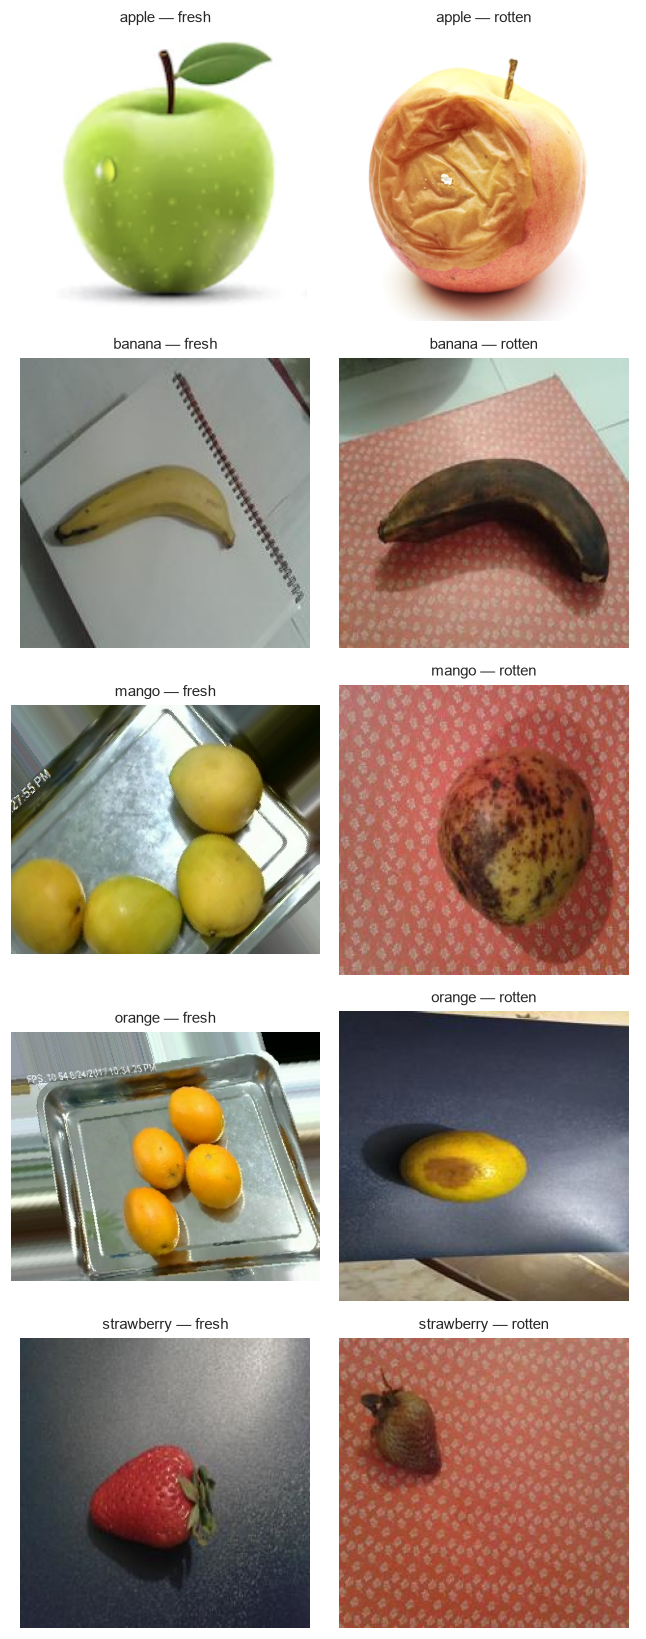

In [8]:
produce_types = sorted(df["produce_type"].unique())
fig, axes = plt.subplots(len(produce_types), 2, figsize=(6, 3 * len(produce_types)))

for i, produce in enumerate(produce_types):
    for j, condition in enumerate(["fresh", "rotten"]):
        subset = df[(df["produce_type"] == produce) & (df["condition"] == condition)]
        ax = axes[i, j]
        if len(subset) > 0:
            sample_path = subset.sample(1, random_state=RANDOM_SEED)["filepath"].values[0]
            img = Image.open(sample_path)
            ax.imshow(img)
        ax.set_title(f"{produce} — {condition}", fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.savefig("sample_grid.png", bbox_inches="tight")
plt.show()


## 5. Image Dimension and Aspect Ratio Analysis

CNNs need a fixed input size, so we first check how much the raw images vary in resolution and
aspect ratio. This directly informs the resize target chosen in the feature engineering section.

In [9]:
sample_n = min(1500, len(df))
sample_df = df.sample(sample_n, random_state=RANDOM_SEED).copy()

widths, heights, modes = [], [], []
for path in sample_df["filepath"]:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception:
        widths.append(np.nan)
        heights.append(np.nan)
        modes.append("ERROR")

sample_df["width"] = widths
sample_df["height"] = heights
sample_df["mode"] = modes
sample_df["aspect_ratio"] = sample_df["width"] / sample_df["height"]

sample_df[["width", "height", "aspect_ratio"]].describe()


,width,height,aspect_ratio
count,1500.000000,1500.000000,1500.000000
mean,294.939333,264.248667,1.098871
std,182.486834,146.316918,0.172531
min,100.000000,100.000000,0.617284
25%,224.000000,224.000000,1.000000
50%,224.000000,224.000000,1.000000
75%,320.000000,258.000000,1.240310
max,3648.000000,2736.000000,1.906780


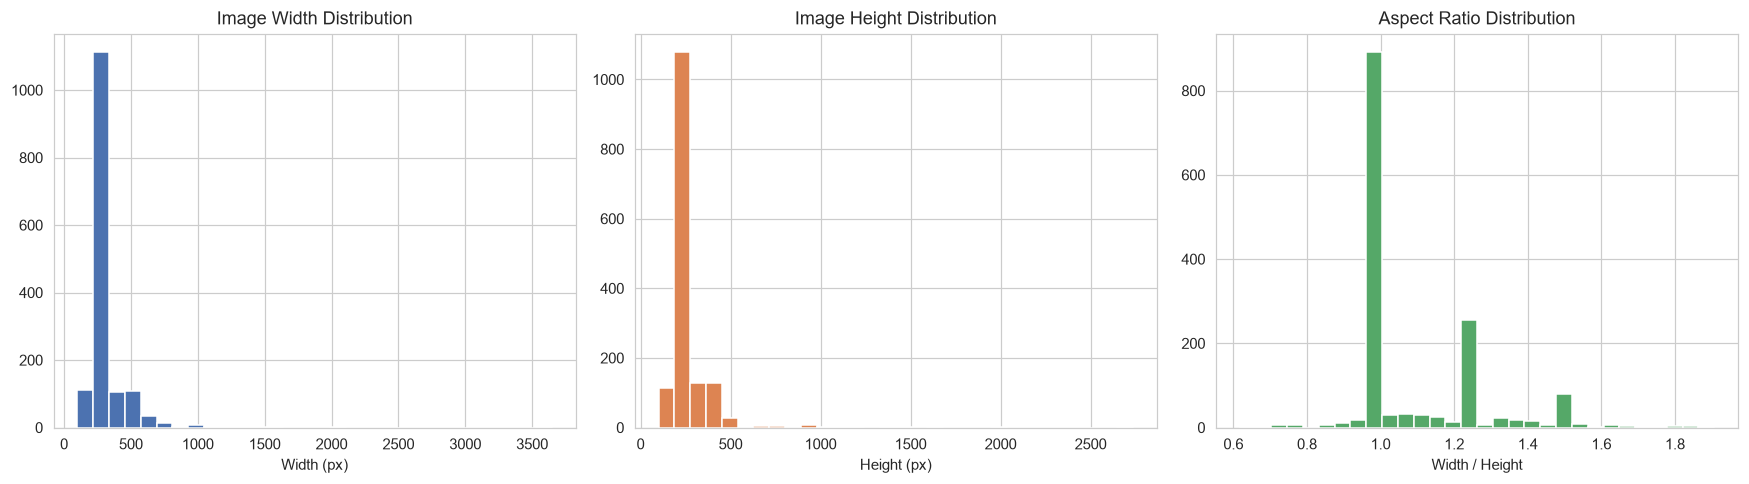

Color modes found: {'RGB': 1473, 'RGBA': 27}


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(sample_df["width"].dropna(), bins=30, color="#4C72B0")
axes[0].set_title("Image Width Distribution")
axes[0].set_xlabel("Width (px)")

axes[1].hist(sample_df["height"].dropna(), bins=30, color="#DD8452")
axes[1].set_title("Image Height Distribution")
axes[1].set_xlabel("Height (px)")

axes[2].hist(sample_df["aspect_ratio"].dropna(), bins=30, color="#55A868")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].set_xlabel("Width / Height")

plt.tight_layout()
plt.savefig("dimension_distributions.png", bbox_inches="tight")
plt.show()

print("Color modes found:", sample_df["mode"].value_counts().to_dict())


## 6. Color and Brightness Analysis — Fresh vs. Rotten

Color degradation (browning, dark spots, dullness) is one of the strongest visual cues of spoilage,
so it is worth quantifying before modeling. For a sample of images we compute mean RGB channel
values, overall brightness (mean pixel intensity), and saturation (via HSV), then compare the fresh
and rotten groups.

In [11]:
import colorsys

def image_color_stats(path, resize_to=(64, 64)):
    with Image.open(path) as img:
        img = img.convert("RGB").resize(resize_to)
        arr = np.asarray(img).astype(np.float32) / 255.0
        r_mean, g_mean, b_mean = arr[..., 0].mean(), arr[..., 1].mean(), arr[..., 2].mean()
        brightness = arr.mean()
        hsv = np.array(Image.fromarray((arr * 255).astype(np.uint8)).convert("HSV")) / 255.0
        saturation = hsv[..., 1].mean()
        return r_mean, g_mean, b_mean, brightness, saturation

color_sample = df.sample(min(800, len(df)), random_state=RANDOM_SEED).copy()
stats = color_sample["filepath"].apply(image_color_stats)
color_sample[["r_mean", "g_mean", "b_mean", "brightness", "saturation"]] = pd.DataFrame(
    stats.tolist(), index=color_sample.index
)
color_sample.head()


,filepath,class_name,condition,produce_type,r_mean,g_mean,b_mean,brightness,saturation
3574,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,RottenApple,rotten,apple,0.790880,0.819942,0.731335,0.780719,0.172650
5792,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,RottenStrawberry,rotten,strawberry,0.493034,0.469885,0.457152,0.473357,0.146529
4162,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,RottenBanana,rotten,banana,0.546920,0.528908,0.587881,0.554570,0.223302
1609,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,FreshMango,fresh,mango,0.584453,0.555248,0.521982,0.553894,0.175444
3727,C:\Users\Chris\Downloads\fruit_veg_data\Fruits...,RottenBanana,rotten,banana,0.630690,0.652763,0.680351,0.654601,0.160764


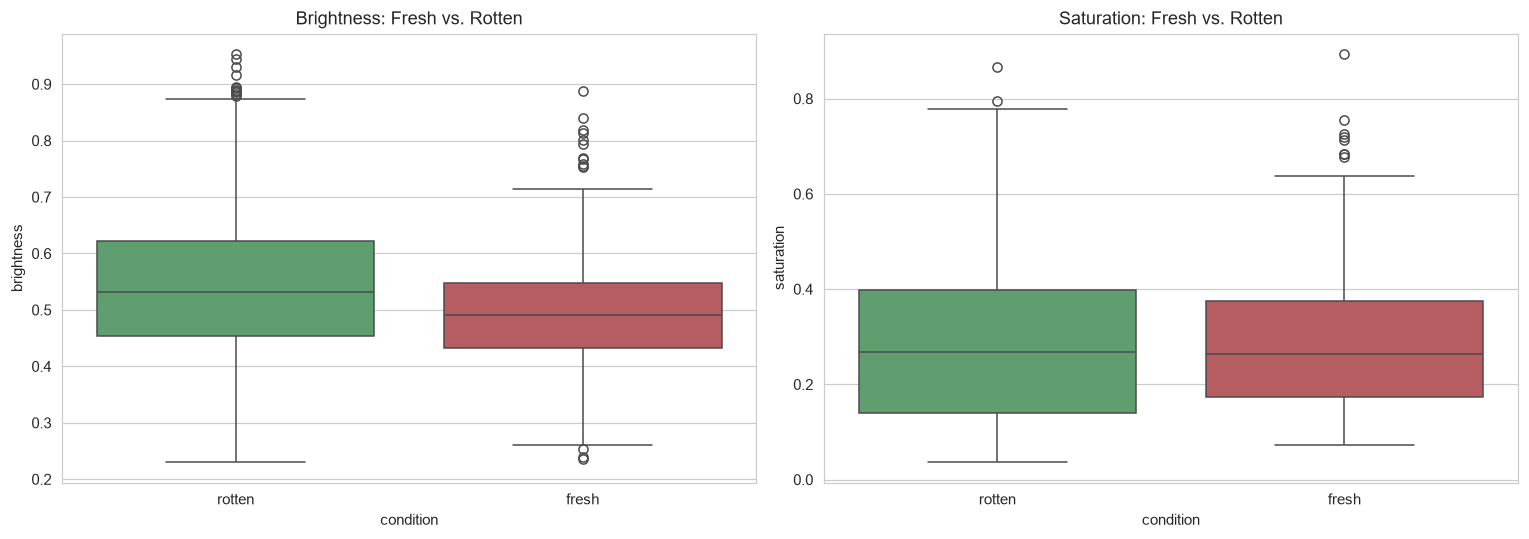

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=color_sample, x="condition", y="brightness", ax=axes[0], palette=["#55A868", "#C44E52"])
axes[0].set_title("Brightness: Fresh vs. Rotten")

sns.boxplot(data=color_sample, x="condition", y="saturation", ax=axes[1], palette=["#55A868", "#C44E52"])
axes[1].set_title("Saturation: Fresh vs. Rotten")

plt.tight_layout()
plt.savefig("brightness_saturation.png", bbox_inches="tight")
plt.show()


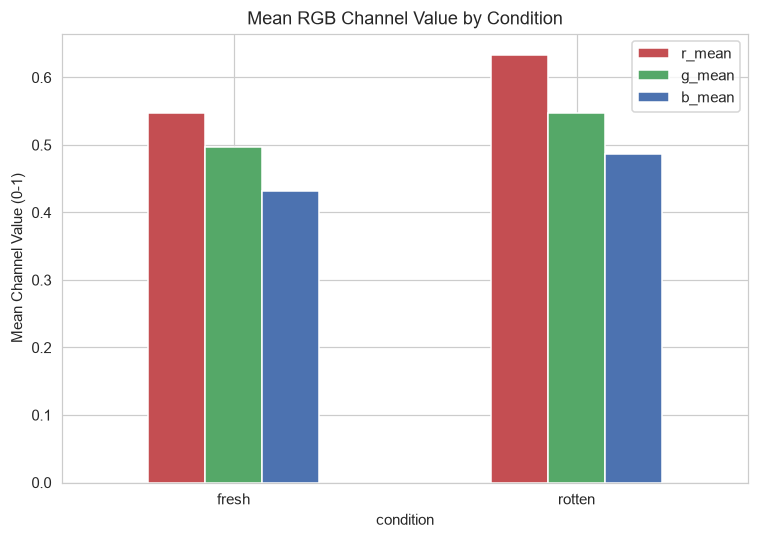

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
channel_means = color_sample.groupby("condition")[["r_mean", "g_mean", "b_mean"]].mean()
channel_means.plot(kind="bar", ax=ax, color=["#C44E52", "#55A868", "#4C72B0"])
ax.set_title("Mean RGB Channel Value by Condition")
ax.set_ylabel("Mean Channel Value (0-1)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rgb_channels_by_condition.png", bbox_inches="tight")
plt.show()


**Observation:** note here whether rotten samples trend darker / less saturated / shifted
toward brown-red tones compared to fresh samples in your run — this justifies color as an
informative feature for the CNN even though the network will learn it automatically from raw
pixels.

## 7. Data Quality Check — Corrupt or Unreadable Images

Before training, every file should be verified as a loadable image so a single bad file does not
crash a long training run.

In [14]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

check_sample = df.sample(min(2000, len(df)), random_state=RANDOM_SEED).copy()
check_sample["is_valid"] = check_sample["filepath"].apply(is_valid_image)

n_bad = (~check_sample["is_valid"]).sum()
print(f"Checked {len(check_sample)} images — {n_bad} unreadable/corrupt in this sample.")
if n_bad > 0:
    display(check_sample[~check_sample["is_valid"]][["filepath", "class_name"]])


Checked 2000 images — 0 unreadable/corrupt in this sample.


## 8. Feature Engineering for the CNN Pipeline

With the exploratory findings above, the following preprocessing decisions are made for the
upcoming CNN implementation:

1. **Resize target:** based on the width/height distribution in Section 5, all images will be
   resized to a fixed shape (e.g. `128x128` or `224x224`) with aspect-ratio-preserving padding
   where needed, rather than naive stretching.
2. **Normalization:** pixel values will be rescaled from `[0, 255]` to `[0, 1]` (or standardized
   using ImageNet mean/std if a pretrained backbone is used later).
3. **Label encoding:** two label schemes are prepared — a 20-class fine-grained label
   (`produce_type` + `condition`) and a binary `fresh` / `rotten` label — so the next assignment
   can experiment with either a multi-class or binary CNN head.
4. **Train / validation / test split:** a stratified split keeps class proportions consistent
   across splits.
5. **Class imbalance handling:** class weights (or oversampling) will be computed from the
   training split if any class is under-represented.
6. **Data augmentation:** since produce photos can appear at different angles, lighting, and
   orientations, on-the-fly augmentation (rotation, horizontal flip, brightness/contrast jitter,
   slight zoom) will be applied to the training split only.


### 8.1 Label encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

le_fine = LabelEncoder()
df["label_fine"] = le_fine.fit_transform(df["class_name"])

le_binary = LabelEncoder()
df["label_binary"] = le_binary.fit_transform(df["condition"])  # fresh=0 / rotten=1 (order may vary)

print("Fine-grained classes:", list(le_fine.classes_))
print("Binary classes:", list(le_binary.classes_))
df[["filepath", "class_name", "produce_type", "condition", "label_fine", "label_binary"]].head()


ModuleNotFoundError: No module named 'sklearn'

### 8.2 Stratified train / validation / test split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["class_name"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class_name"], random_state=RANDOM_SEED
)

print(f"Train: {len(train_df):,}  |  Validation: {len(val_df):,}  |  Test: {len(test_df):,}")

split_sizes = pd.Series(
    {"train": len(train_df), "validation": len(val_df), "test": len(test_df)}
)
fig, ax = plt.subplots(figsize=(5, 4))
split_sizes.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Train / Validation / Test Split Sizes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("split_sizes.png", bbox_inches="tight")
plt.show()

train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)


### 8.3 Class imbalance check on the training split

In [ ]:
train_counts = train_df["class_name"].value_counts().sort_index()
imbalance_ratio = train_counts.max() / train_counts.min()
print(f"Training class counts range from {train_counts.min()} to {train_counts.max()} "
      f"(imbalance ratio: {imbalance_ratio:.2f})")

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_fine"]),
    y=train_df["label_fine"],
)
class_weight_dict = dict(zip(np.unique(train_df["label_fine"]), class_weights))
print("Computed class weights ready to pass into the CNN's loss function next assignment.")


### 8.4 Augmentation preview

A visual before/after check that the planned augmentations produce realistic, still-recognizable produce images.

In [ ]:
from PIL import ImageEnhance

def augment_preview(img):
    img = img.rotate(random.uniform(-25, 25), expand=False, fillcolor=(255, 255, 255))
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    return img

sample_paths = train_df.sample(4, random_state=RANDOM_SEED)["filepath"].tolist()
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, path in enumerate(sample_paths):
    original = Image.open(path).convert("RGB").resize((160, 160))
    augmented = augment_preview(original.copy())
    axes[0, i].imshow(original)
    axes[0, i].set_title("Original", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(augmented)
    axes[1, i].set_title("Augmented", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("augmentation_preview.png", bbox_inches="tight")
plt.show()


## 9. Summary of Findings

- **Dataset size and shape:** *(fill in actual counts from Section 3 after running)*
- **Class balance:** *(fill in — roughly even per the dataset documentation, ~600 images/class)*
- **Image dimensions:** *(fill in the dominant resolution / range from Section 5 — informs the
  resize target)*
- **Color signal:** *(fill in whether brightness/saturation clearly separates fresh vs. rotten in
  Section 6 — supports that the CNN has a learnable visual signal to exploit)*
- **Data quality:** *(fill in corrupt-image count from Section 7)*
- **Feature engineering decisions carried into the next assignment:** fixed resize target,
  `[0, 1]` normalization, two label schemes (20-class and binary), stratified 70/15/15 split,
  class weighting, and on-the-fly augmentation for the training split.

This EDA confirms the dataset is suitable for a CNN-based freshness classifier and establishes the
preprocessing pipeline to be implemented in the next assignment.
